# Zadanie 6: Model PINN (Physics-Informed Neural Network)

W tym zadaniu stworzymy model PINN (Physics-Informed Neural Network) dla naszego równania reakcji-dyfuzji.
Model ten będzie uczył się rozwiązania $u(x,t)$ korzystając z:
1.  **Danych symulacyjnych (zasymilowanych)** - punktów pomiarowych z "rzeczywistości" (wygenerowanych przez solver PDE).
2.  **Wiedzy fizycznej (równania PDE)** - minimalizacji residuum równania różniczkowego w losowych punktach kolokacji.

Porównamy wyniki predykcji PINN z oryginalną symulacją PDE oraz modelem surogatowym ODE.

In [5]:
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.interpolate import griddata

# Dodanie ścieżki do zad2
sys.path.append(os.path.abspath(os.path.join('..', 'zad2')))

# Ustawienie ziarna i urządzenia
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Katalog na wyniki
OUTDIR = Path("results")
OUTDIR.mkdir(exist_ok=True)

# Parametry fizyczne (bardziej stromy/niestabilny przypadek)
PARAMS = {
    'D': 0.02,
    'p': 0.05,
    'q': 4.0
}
T_END = 5.0
NX = 150
DT = 5e-4

# Konfiguracja szumu i treningu
NOISE_LEVEL = 0.05  # amplituda szumu względem |u|
NOISE_KIND = "gaussian_mixture"  # gaussian, laplace, gaussian_mixture
N_DATA = 1200
N_COLLOCATION = 12000
LAMBDA_PHY = 2.0


Using device: cpu


In [6]:
# Egzekwowanie bieżącej konfiguracji (dla pewności po restarcie kernela)
NX = 150
DT = 5e-4
N_DATA = 1200
N_COLLOCATION = 12000
print(f"Configured NX={NX}, DT={DT}, N_DATA={N_DATA}, N_COLLOCATION={N_COLLOCATION}")

Configured NX=150, DT=0.0005, N_DATA=1200, N_COLLOCATION=12000


In [7]:
# --- Generowanie Danych Ground Truth (PDE) ---

def add_noise(u, kind, level, rng):
    """Dodaje zakładany szum pomiarowy do pola u."""
    scale = level * np.maximum(1e-3, np.abs(u))
    if kind == "gaussian":
        noise = rng.normal(0.0, scale)
    elif kind == "laplace":
        noise = rng.laplace(0.0, scale)
    elif kind == "gaussian_mixture":
        comp = rng.choice([0, 1, 2], size=u.shape, p=[0.7, 0.2, 0.1])
        noise = np.where(
            comp == 0,
            rng.normal(0.0, scale),
            np.where(
                comp == 1,
                rng.laplace(0.0, 1.5 * scale),
                rng.normal(0.0, 3.0 * scale),
            ),
        )
    else:
        raise ValueError(f"Unsupported noise kind: {kind}")
    return u + noise


def generate_pde_data():
    """Generuje pełne rozwiązanie PDE jako Ground Truth."""
    try:
        from solvers import _neumann_laplacian, reaction, initial_condition
        import scipy.sparse as sp
        import scipy.sparse.linalg as spla

        # Parametry
        nx = NX
        dt = DT
        tend = T_END
        D = PARAMS['D']
        p = PARAMS['p']
        q = PARAMS['q']

        dx = 1.0 / (nx - 1)
        x = np.linspace(0, 1, nx)
        u = initial_condition(nx, dx, kind='localized')

        A = _neumann_laplacian(nx, dx)

        # Crank-Nicolson matrices
        M_l = sp.eye(nx) - 0.5 * dt * D * A
        M_r = sp.eye(nx) + 0.5 * dt * D * A

        nsteps = int(np.ceil(tend / dt))

        # Zbieramy wyniki
        u_all = [u.copy()]
        t_all = [0.0]

        current_t = 0.0
        for n in range(nsteps):
            Ru = reaction(u, p, q)
            rhs = M_r.dot(u) + dt * Ru
            u = spla.spsolve(M_l, rhs)
            current_t += dt

            if (n + 1) % 10 == 0:
                u_all.append(u.copy())
                t_all.append(current_t)

        u_matrix = np.array(u_all).T  # (NX, NT)
        t_vector = np.array(t_all)

        return x, t_vector, u_matrix

    except ImportError as e:
        print(f"Błąd importu solvera: {e}. Używam uproszczonej generacji.")
        return None, None, None


x_true, t_true, u_true_clean = generate_pde_data()

if x_true is not None:
    rng = np.random.default_rng(123)
    u_true_noisy = add_noise(u_true_clean, NOISE_KIND, NOISE_LEVEL, rng)
    print(
        f"Wygenerowano dane PDE. Kształt u_true: {u_true_clean.shape}, t_true: {t_true.shape}"
    )

    # Przygotowanie danych treningowych dla PINN
    X, T = np.meshgrid(x_true, t_true)  # X, T shape: (NT, NX)

    # Spłaszczamy do formatu (N, 2) -> (x, t) i (N, 1) -> u
    X_flat = X.flatten()[:, None]
    T_flat = T.flatten()[:, None]
    u_flat_clean = u_true_clean.T.flatten()[:, None]
    u_flat_noisy = u_true_noisy.T.flatten()[:, None]

    # Wybieramy losowe punkty "pomiarowe" (Data Loss)
    idx = rng.choice(X_flat.shape[0], N_DATA, replace=False)

    X_train = np.hstack((X_flat[idx], T_flat[idx]))
    u_train = u_flat_noisy[idx]

    # Punkty kolokacji (Physics Loss)
    rng_coll = np.random.default_rng(1234)
    X_collocation = rng_coll.uniform(0, 1, (N_COLLOCATION, 1))
    T_collocation = rng_coll.uniform(0, T_END, (N_COLLOCATION, 1))
    XT_collocation = np.hstack((X_collocation, T_collocation))

    # Konwersja na tensory
    X_u_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    u_train_tensor = torch.tensor(u_train, dtype=torch.float32).to(device)
    X_f_train = torch.tensor(XT_collocation, dtype=torch.float32).to(device)

    print(f"Dane treningowe: {X_u_train.shape}, Punkty kolokacji: {X_f_train.shape}")
else:
    print("Nie udało się wygenerować danych.")


Wygenerowano dane PDE. Kształt u_true: (150, 1001), t_true: (1001,)
Dane treningowe: torch.Size([1200, 2]), Punkty kolokacji: torch.Size([12000, 2])


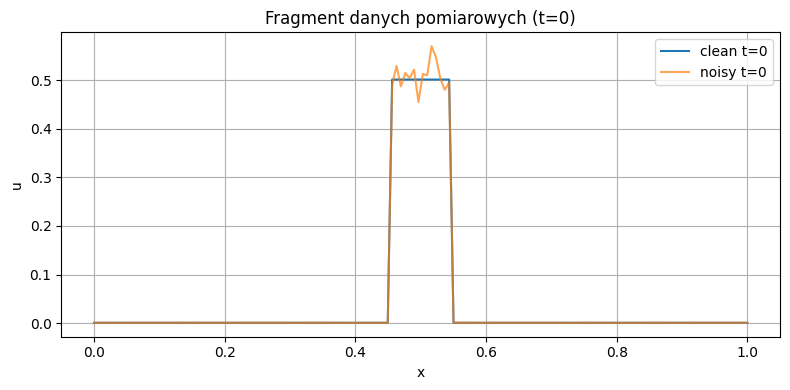

In [8]:
# Podgląd szumu: czyste vs zaszumione t=0
if x_true is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(x_true, u_true_clean[:, 0], label='clean t=0')
    plt.plot(x_true, u_true_noisy[:, 0], label='noisy t=0', alpha=0.7)
    plt.title('Fragment danych pomiarowych (t=0)')
    plt.xlabel('x')
    plt.ylabel('u')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTDIR / 'noise_slice_t0.png')
    plt.show()


Rozpoczynam trening PINN...
Epoch 400/2000, Loss: 0.793500 (Data: 0.761806, Phy: 0.015847)
Epoch 800/2000, Loss: 0.790025 (Data: 0.760101, Phy: 0.014962)
Epoch 1200/2000, Loss: 0.788821 (Data: 0.755613, Phy: 0.016604)
Epoch 1600/2000, Loss: 0.789452 (Data: 0.753557, Phy: 0.017948)
Epoch 2000/2000, Loss: 0.574669 (Data: 0.051771, Phy: 0.261449)
Trening zakończony w 42.77s


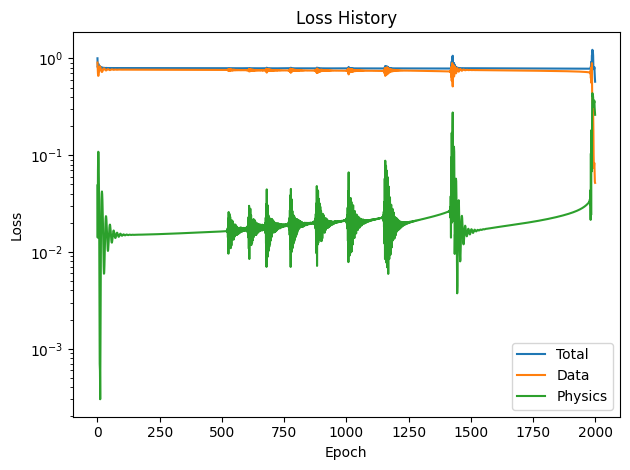

In [9]:
# --- Definicja Modelu PINN ---

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Prosta sieć MLP: wejście (x, t) -> wyjście u
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1)
        )

    def forward(self, x, t):
        # Łączymy x i t w jeden tensor wejściowy
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)


def physics_loss(model, x, t, params):
    """Oblicza residuum równania PDE."""
    x.requires_grad = True
    t.requires_grad = True

    u = model(x, t)

    # Obliczamy pochodne cząstkowe
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    D = params['D']
    p = params['p']
    q = params['q']

    # Residuum: f = u_t - D*u_xx - (p + q*u)*(1 - u)
    f = u_t - D * u_xx - (p + q * u) * (1 - u)

    return torch.mean(f ** 2)


# Inicjalizacja modelu
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Pętla treningowa
epochs = 2000
loss_history = []

print("Rozpoczynam trening PINN...")
start_time = time.time()

for epoch in range(epochs):
    optimizer.zero_grad()

    # 1. Data Loss (MSE na punktach pomiarowych)
    x_data = X_u_train[:, 0:1]
    t_data = X_u_train[:, 1:2]
    u_pred = model(x_data, t_data)
    loss_data = torch.mean((u_pred - u_train_tensor) ** 2)

    # 2. Physics Loss (Residuum PDE w punktach kolokacji)
    x_col = X_f_train[:, 0:1]
    t_col = X_f_train[:, 1:2]
    loss_phy = physics_loss(model, x_col, t_col, PARAMS)

    # Całkowita strata z wzmocnieniem części fizycznej, aby nie przeuczyć szumu
    loss = loss_data + LAMBDA_PHY * loss_phy

    loss.backward()
    optimizer.step()

    loss_history.append((loss.item(), loss_data.item(), loss_phy.item()))

    if (epoch + 1) % 400 == 0:
        print(
            f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f} "
            f"(Data: {loss_data.item():.6f}, Phy: {loss_phy.item():.6f})"
        )

train_time = time.time() - start_time
print(f"Trening zakończony w {train_time:.2f}s")

loss_arr = np.array(loss_history)
plt.figure()
plt.plot(loss_arr[:, 0], label='Total')
plt.plot(loss_arr[:, 1], label='Data')
plt.plot(loss_arr[:, 2], label='Physics')
plt.yscale('log')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'loss_history.png')
plt.show()


PINN Evaluation: MAE = 0.185509, RMSE = 0.235925, relL2 = 0.264733


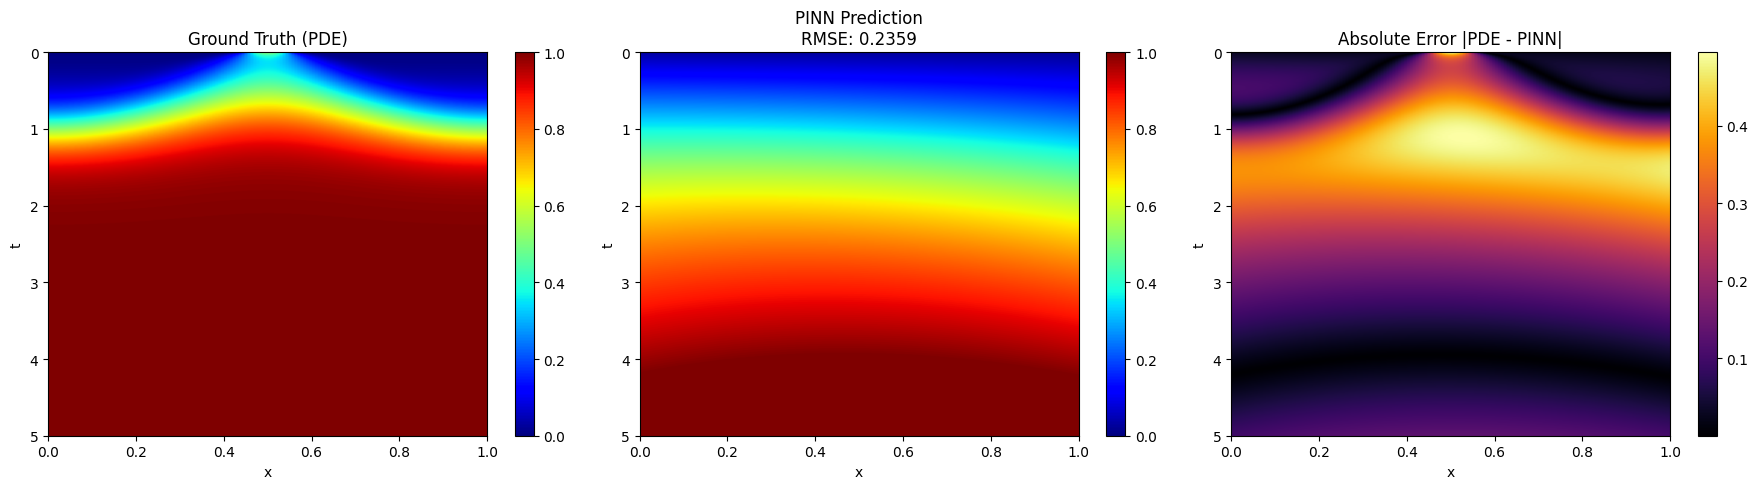

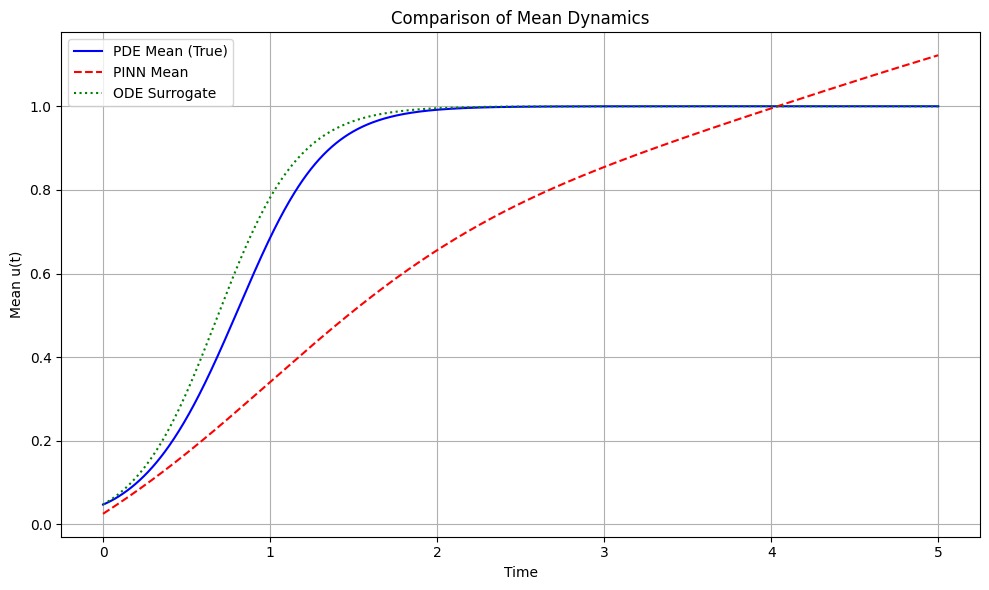

In [10]:
# --- Ewaluacja i Porównanie ---

# Generujemy predykcje na pełnej siatce
X_grid, T_grid = np.meshgrid(x_true, t_true)
X_flat_eval = X_grid.flatten()[:, None]
T_flat_eval = T_grid.flatten()[:, None]

x_eval_tensor = torch.tensor(X_flat_eval, dtype=torch.float32).to(device)
t_eval_tensor = torch.tensor(T_flat_eval, dtype=torch.float32).to(device)

with torch.no_grad():
    u_pred_flat = model(x_eval_tensor, t_eval_tensor).cpu().numpy()

u_pred_grid = u_pred_flat.reshape(X_grid.shape)  # (NT, NX)

# Obliczamy błędy
abs_error = np.abs(u_true_clean.T - u_pred_grid)
mae = np.mean(abs_error)
rmse = np.sqrt(np.mean(abs_error ** 2))
rel_l2 = np.linalg.norm(u_true_clean.T - u_pred_grid) / np.linalg.norm(u_true_clean.T)

print(f"PINN Evaluation: MAE = {mae:.6f}, RMSE = {rmse:.6f}, relL2 = {rel_l2:.6f}")

# --- Model ODE (Surogatowy) ---
# Rozwiązujemy ODE dla porównania

def ode_func(t, U):
    return (PARAMS['p'] + PARAMS['q'] * U) * (1 - U)

u0_mean = np.mean(u_true_clean[:, 0])  # Średnia z warunku początkowego
from scipy.integrate import solve_ivp
sol_ode = solve_ivp(ode_func, [t_true[0], t_true[-1]], [u0_mean], t_eval=t_true)
u_ode = sol_ode.y.T  # (NT, 1)

# --- Wizualizacja ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Ground Truth
im1 = axes[0].imshow(u_true_clean.T, extent=[0, 1, T_END, 0], aspect='auto', cmap='jet', vmin=0, vmax=1)
axes[0].set_title('Ground Truth (PDE)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
plt.colorbar(im1, ax=axes[0])

# 2. PINN Prediction
im2 = axes[1].imshow(u_pred_grid, extent=[0, 1, T_END, 0], aspect='auto', cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f'PINN Prediction\nRMSE: {rmse:.4f}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
plt.colorbar(im2, ax=axes[1])

# 3. Absolute Error
im3 = axes[2].imshow(abs_error, extent=[0, 1, T_END, 0], aspect='auto', cmap='inferno')
axes[2].set_title('Absolute Error |PDE - PINN|')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig(OUTDIR / 'pinn_results_heatmap.png')
plt.show()

# Porównanie w czasie (średnia przestrzenna)
u_pinn_mean = np.mean(u_pred_grid, axis=1)
u_true_mean = np.mean(u_true_clean.T, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(t_true, u_true_mean, 'b-', label='PDE Mean (True)')
plt.plot(t_true, u_pinn_mean, 'r--', label='PINN Mean')
plt.plot(t_true, u_ode, 'g:', label='ODE Surrogate')
plt.title('Comparison of Mean Dynamics')
plt.xlabel('Time')
plt.ylabel('Mean u(t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTDIR / 'pinn_vs_pde_vs_ode.png')
plt.show()
